# JS05: Tugas Lab 1
## Klasifikasi suara dengan kNN

## Persiapan data
Dataset voice berisi 20 fitur akustik dan label male atau female. Jika file belum ada, notebook mengunduhnya otomatis.

In [1]:
from pathlib import Path
from urllib.request import Request, urlopen

data_path = Path("voice.csv")
if not data_path.exists():
    request = Request("https://1812311909-files.gitbook.io/~/files/v0/b/gitbook-x-prod.appspot.com/o/spaces%2FYHOv2XH8FJMJSMsnhwNa%2Fuploads%2FRaxNX654qm80v449qVUR%2Fvoice.csv?alt=media&token=86415498-33a5-44c9-ba27-bf1e56ad7c54", headers={"User-Agent": "Mozilla/5.0"})
    with urlopen(request) as response:
        data_path.write_bytes(response.read())
print(f"Dataset siap: {data_path.resolve()}")

Dataset siap: D:\Machine Learning\JS05\voice.csv


## Load dan pemeriksaan data

In [2]:
import pandas as pd

voice = pd.read_csv(data_path)
voice.head()

,meanfreq,sd,median,Q25,Q75,IQR,skew,kurt,sp.ent,sfm,...,centroid,meanfun,minfun,maxfun,meandom,mindom,maxdom,dfrange,modindx,label
0,0.059781,0.064241,0.032027,0.015071,0.090193,0.075122,12.863462,274.402906,0.893369,0.491918,...,0.059781,0.084279,0.015702,0.275862,0.007812,0.007812,0.007812,0.000000,0.000000,male
1,0.066009,0.067310,0.040229,0.019414,0.092666,0.073252,22.423285,634.613855,0.892193,0.513724,...,0.066009,0.107937,0.015826,0.250000,0.009014,0.007812,0.054688,0.046875,0.052632,male
2,0.077316,0.083829,0.036718,0.008701,0.131908,0.123207,30.757155,1024.927705,0.846389,0.478905,...,0.077316,0.098706,0.015656,0.271186,0.007990,0.007812,0.015625,0.007812,0.046512,male
3,0.151228,0.072111,0.158011,0.096582,0.207955,0.111374,1.232831,4.177296,0.963322,0.727232,...,0.151228,0.088965,0.017798,0.250000,0.201497,0.007812,0.562500,0.554688,0.247119,male
4,0.135120,0.079146,0.124656,0.078720,0.206045,0.127325,1.101174,4.333713,0.971955,0.783568,...,0.135120,0.106398,0.016931,0.266667,0.712812,0.007812,5.484375,5.476562,0.208274,male


In [3]:
print(voice.shape)
print(voice["label"].value_counts())
print(voice.info())

(3168, 21)
label
male      1584
female    1584
Name: count, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 3168 entries, 0 to 3167
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   meanfreq  3168 non-null   float64
 1   sd        3168 non-null   float64
 2   median    3168 non-null   float64
 3   Q25       3168 non-null   float64
 4   Q75       3168 non-null   float64
 5   IQR       3168 non-null   float64
 6   skew      3168 non-null   float64
 7   kurt      3168 non-null   float64
 8   sp.ent    3168 non-null   float64
 9   sfm       3168 non-null   float64
 10  mode      3168 non-null   float64
 11  centroid  3168 non-null   float64
 12  meanfun   3168 non-null   float64
 13  minfun    3168 non-null   float64
 14  maxfun    3168 non-null   float64
 15  meandom   3168 non-null   float64
 16  mindom    3168 non-null   float64
 17  maxdom    3168 non-null   float64
 18  dfrange   3168 non-null   float64
 19  modindx

## Percobaan fitur

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

all_features = [column for column in voice.columns if column != "label"]
feature_sets = {
    "Semua fitur": all_features,
    "Fitur utama": ["meanfun", "meanfreq", "sd", "IQR", "Q25", "Q75"],
    "Meanfun": ["meanfun"],
    "Fitur spektral": ["meanfreq", "median", "Q25", "Q75", "IQR", "centroid"],
    "Fitur statistik": ["sd", "skew", "kurt", "sp.ent", "sfm", "IQR"],
}
X = voice[all_features]
y = voice["label"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

feature_results = []
for name, features in feature_sets.items():
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=10)),
    ])
    model.fit(X_train[features], y_train)
    feature_results.append({"Fitur": name, "Akurasi": model.score(X_test[features], y_test)})

feature_results = pd.DataFrame(feature_results).sort_values("Akurasi", ascending=False)
feature_results

,Fitur,Akurasi
1,Fitur utama,0.982124
0,Semua fitur,0.969506
2,Meanfun,0.950578
4,Fitur statistik,0.950578
3,Fitur spektral,0.941115


Fitur utama memberi akurasi tertinggi pada percobaan awal. Fitur ini dipakai untuk memilih nilai k.

## Menentukan nilai k

Fitur terpilih: ['meanfun', 'meanfreq', 'sd', 'IQR', 'Q25', 'Q75']
Nilai k terbaik: 10
Akurasi data train: 0.9788001804239964
Akurasi data test: 0.982124079915878


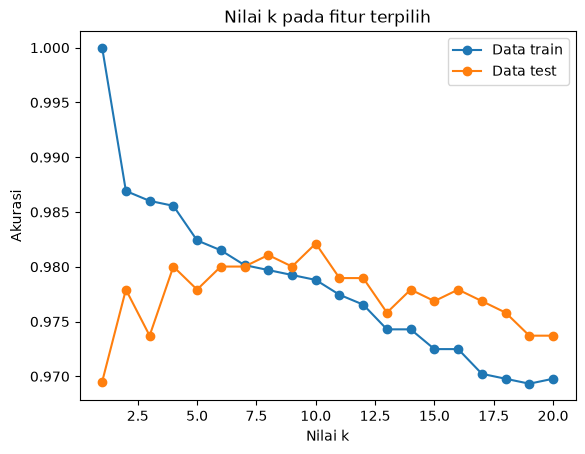

In [5]:
import matplotlib.pyplot as plt

selected_features = feature_sets["Fitur utama"]
k_values = range(1, 21)
train_accuracy = []
test_accuracy = []

for k in k_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k)),
    ])
    model.fit(X_train[selected_features], y_train)
    train_accuracy.append(model.score(X_train[selected_features], y_train))
    test_accuracy.append(model.score(X_test[selected_features], y_test))

best_index = test_accuracy.index(max(test_accuracy))
best_k = list(k_values)[best_index]
print(f"Fitur terpilih: {selected_features}")
print(f"Nilai k terbaik: {best_k}")
print(f"Akurasi data train: {train_accuracy[best_index]}")
print(f"Akurasi data test: {test_accuracy[best_index]}")

plt.plot(k_values, train_accuracy, marker="o", label="Data train")
plt.plot(k_values, test_accuracy, marker="o", label="Data test")
plt.xlabel("Nilai k")
plt.ylabel("Akurasi")
plt.title("Nilai k pada fitur terpilih")
plt.legend()
plt.show()

## Jawaban
Fitur utama yang dipakai adalah meanfun, meanfreq, sd, IQR, Q25, dan Q75. Pada pembagian data yang sama, nilai k terbaik adalah 10 dengan akurasi data uji 0.9821. Nilai ini dipilih dari grafik akurasi data latih dan data uji.